# GA4 E-commerce User Behavior Analysis

**Dataset:** Google's public GA4 sample e-commerce dataset (`bigquery-public-data.ga4_obfuscated_sample_ecommerce`),
based on real (anonymized) user behavior on the Google Merchandise Store, Dec 2020 - Jan 2021.

**Goal:** Understand where users drop off in the purchase funnel, which traffic channels convert best,
and whether paid advertising (Google CPC) is actually performing worse than organic/direct traffic.

**Tools used:** BigQuery (SQL) → Python (pandas, scipy) → Tableau Public (dashboard)

**Live dashboard:** [GA4 E-commerce Behavior Analysis on Tableau Public](https://public.tableau.com/) *(replace with your actual link)*

---


## Setup & Authentication

Connect to BigQuery using the project's sandbox (no billing required for this analysis — all queries run on Google's free public dataset).

In [1]:
from google.cloud import bigquery
import pandas as pd

# Authenticate with your Google account inside Colab
from google.colab import auth
auth.authenticate_user()

# Replace with your actual GCP project ID (visible in Cloud Console)
PROJECT_ID = "inlaid-fire-488810-t8"
client = bigquery.Client(project=PROJECT_ID)

print("Connection successful!")

Connection successful!


## 1. Conversion Funnel Analysis

How many unique users reach each stage of the purchase journey: viewing a product, adding it to cart,
starting checkout, and completing a purchase? This tells us where the biggest drop-off happens.

In [2]:
# Query 1: Funnel - unique users at each stage
funnel_query = """
SELECT
  COUNT(DISTINCT CASE WHEN event_name = 'view_item' THEN user_pseudo_id END) AS users_view_item,
  COUNT(DISTINCT CASE WHEN event_name = 'add_to_cart' THEN user_pseudo_id END) AS users_add_to_cart,
  COUNT(DISTINCT CASE WHEN event_name = 'begin_checkout' THEN user_pseudo_id END) AS users_begin_checkout,
  COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN user_pseudo_id END) AS users_purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201201' AND '20210131'
"""

df_funnel = client.query(funnel_query).to_dataframe()
df_funnel

,users_view_item,users_add_to_cart,users_begin_checkout,users_purchase
0,41560,10681,5696,2997


## 2. Channel, Device, and Revenue Analysis

Three more queries, run together:
- **Channel conversion:** does the traffic source (Google organic, CPC, direct, referral) affect conversion rate?
- **Device conversion:** does desktop/mobile/tablet affect conversion rate?
- **Revenue by channel:** which channels generate the most total and average revenue per buyer?

In [3]:
# Query 2: Conversion rate by traffic source/medium
channel_query = """
SELECT
  traffic_source.source AS source,
  traffic_source.medium AS medium,
  COUNT(DISTINCT CASE WHEN event_name = 'view_item' THEN user_pseudo_id END) AS users_view_item,
  COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN user_pseudo_id END) AS users_purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201201' AND '20210131'
GROUP BY source, medium
ORDER BY users_purchase DESC
"""
df_channel = client.query(channel_query).to_dataframe()

# Query 3: Conversion rate by device category
device_query = """
SELECT
  device.category AS device_category,
  COUNT(DISTINCT CASE WHEN event_name = 'view_item' THEN user_pseudo_id END) AS users_view_item,
  COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN user_pseudo_id END) AS users_purchase
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201201' AND '20210131'
GROUP BY device_category
ORDER BY users_view_item DESC
"""
df_device = client.query(device_query).to_dataframe()

# Query 4: Revenue by traffic source/medium
revenue_query = """
SELECT
  traffic_source.source AS source,
  traffic_source.medium AS medium,
  COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN user_pseudo_id END) AS users_purchase,
  SUM(CASE WHEN event_name = 'purchase' THEN ecommerce.purchase_revenue_in_usd ELSE 0 END) AS total_revenue
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201201' AND '20210131'
GROUP BY source, medium
ORDER BY total_revenue DESC
"""
df_revenue = client.query(revenue_query).to_dataframe()

print("All queries loaded successfully!")
print(f"Channel data: {df_channel.shape[0]} rows")
print(f"Device data: {df_device.shape[0]} rows")
print(f"Revenue data: {df_revenue.shape[0]} rows")

All queries loaded successfully!
Channel data: 12 rows
Device data: 3 rows
Revenue data: 12 rows


## 3. Statistical Testing — Is Paid Traffic's Lower Conversion Real?

The channel data shows Google CPC (paid search) converting lower than Google Organic. But is that
difference real, or could it just be random noise given the sample size? We test this with a
chi-square test of independence on a 2x2 contingency table (converted vs. not converted, per channel).

In [4]:
from scipy.stats import chi2_contingency
import numpy as np

# Calculate conversion rate for each channel first
df_channel['conversion_rate'] = (df_channel['users_purchase'] / df_channel['users_view_item'] * 100).round(2)

# Exclude '(data deleted)' rows - these are privacy-redacted, not a real channel
df_channel_clean = df_channel[~df_channel['source'].str.contains('data deleted', na=False)].copy()

print("Conversion rate by channel:")
print(df_channel_clean[['source', 'medium', 'users_view_item', 'users_purchase', 'conversion_rate']])

# Chi-square test: Is Google CPC's conversion rate significantly different from Google Organic?
organic_row = df_channel_clean[(df_channel_clean['source'] == 'google') & (df_channel_clean['medium'] == 'organic')].iloc[0]
cpc_row = df_channel_clean[(df_channel_clean['source'] == 'google') & (df_channel_clean['medium'] == 'cpc')].iloc[0]

# Build a 2x2 contingency table: [converted, not converted] for each channel
contingency_table = np.array([
    [organic_row['users_purchase'], organic_row['users_view_item'] - organic_row['users_purchase']],
    [cpc_row['users_purchase'], cpc_row['users_view_item'] - cpc_row['users_purchase']]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: The difference in conversion rate between Organic and CPC IS statistically significant (p < 0.05).")
else:
    print("Result: The difference is NOT statistically significant (p >= 0.05) - could be due to chance.")

Conversion rate by channel:
                             source          medium  users_view_item  \
0                            google         organic            14909   
1                          (direct)          (none)            11062   
3   shop.googlemerchandisestore.com        referral             4091   
4                           <Other>         <Other>             6978   
5                           <Other>        referral             4758   
6                            google             cpc             2056   
7                           <Other>         organic             1402   
8                           <Other>  (data deleted)               59   
10                          <Other>             cpc                1   
11                           google         <Other>                0   

    users_purchase  conversion_rate  
0              841             5.64  
1              716             6.47  
3              378             9.24  
4              325         

**Result:** p = 0.164 — not statistically significant on its own. Google CPC's sample size (2,056 users)
is too small to confidently say its conversion rate differs from Organic. Rather than stop here, we
increase statistical power by grouping all channels into two broader categories: **Paid (CPC)** vs.
**Non-paid (Organic + Direct + Referral)**, and re-test.

In [5]:
# Group channels into Paid vs Non-paid for a more statistically powerful test
paid = df_channel_clean[df_channel_clean['medium'] == 'cpc']
paid_purchase = paid['users_purchase'].sum()
paid_view = paid['users_view_item'].sum()

non_paid = df_channel_clean[df_channel_clean['medium'] != 'cpc']
non_paid_purchase = non_paid['users_purchase'].sum()
non_paid_view = non_paid['users_view_item'].sum()

contingency_table_grouped = np.array([
    [paid_purchase, paid_view - paid_purchase],
    [non_paid_purchase, non_paid_view - non_paid_purchase]
])

chi2_g, p_value_g, dof_g, expected_g = chi2_contingency(contingency_table_grouped)

print(f"Paid conversion rate: {paid_purchase/paid_view*100:.2f}%")
print(f"Non-paid conversion rate: {non_paid_purchase/non_paid_view*100:.2f}%")
print(f"\nChi-square statistic: {chi2_g:.2f}")
print(f"P-value: {p_value_g:.6f}")

if p_value_g < 0.05:
    print("Result: The difference between Paid and Non-paid traffic IS statistically significant (p < 0.05).")
else:
    print("Result: The difference is NOT statistically significant (p >= 0.05).")

Paid conversion rate: 4.86%
Non-paid conversion rate: 6.10%

Chi-square statistic: 5.06
P-value: 0.024526
Result: The difference between Paid and Non-paid traffic IS statistically significant (p < 0.05).


## 4. Visualization — Summary Dashboard

A single 2x2 chart summarizing the four key findings, with colors used consistently to flag concerns
(red) vs. healthy performance (green).

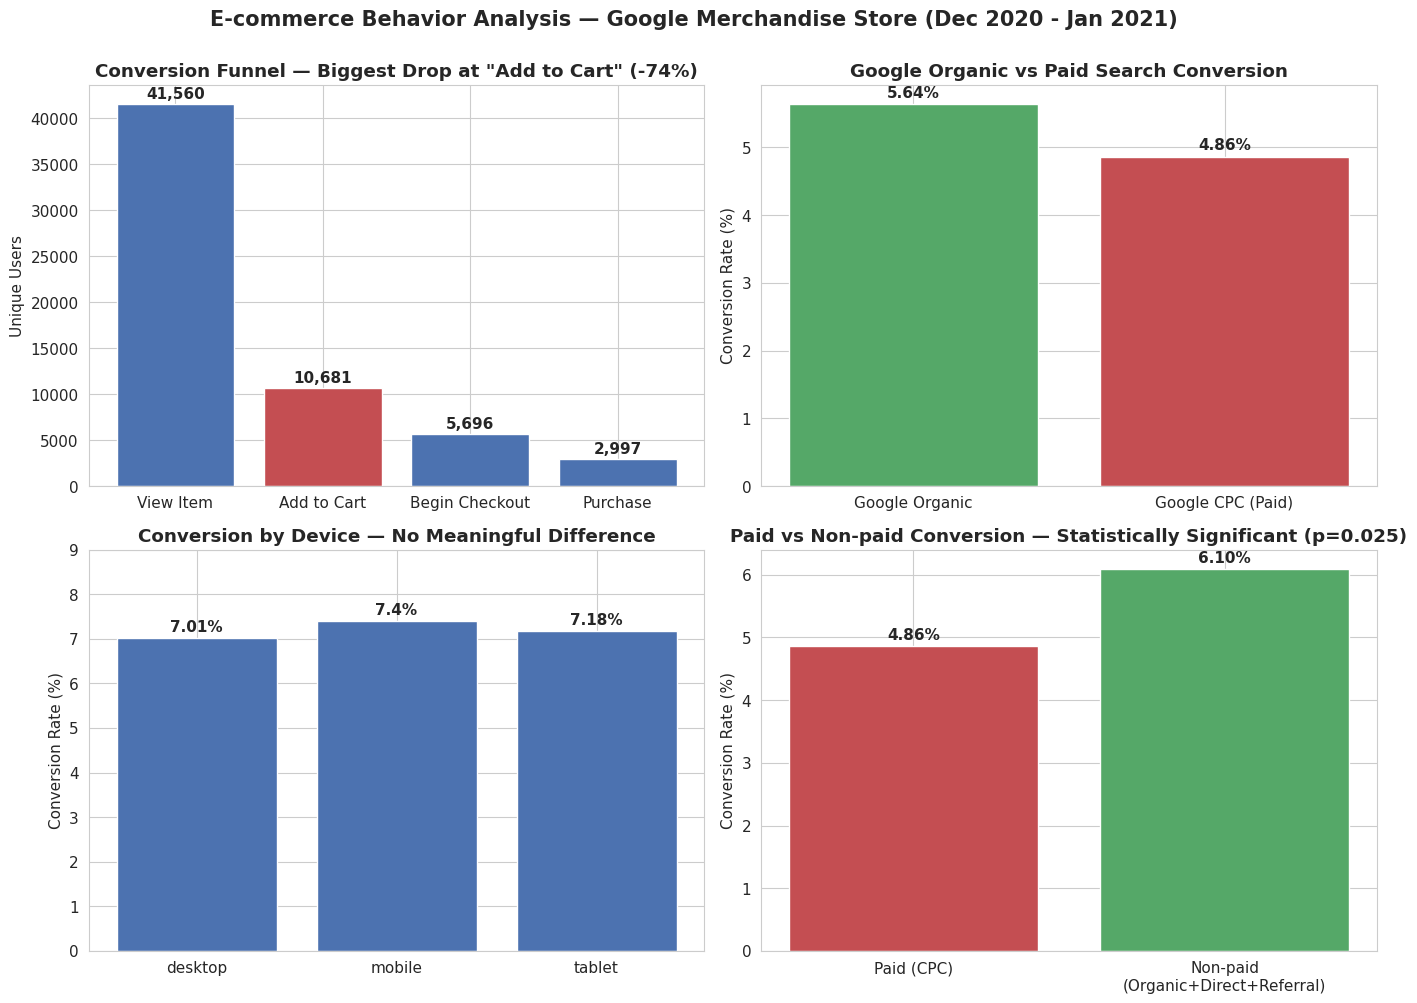

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Consistent color palette used across all 4 charts
COLOR_NEUTRAL = '#4C72B0'   # blue - general/neutral bars
COLOR_GOOD = '#55A868'      # green - positive/non-paid
COLOR_BAD = '#C44E52'       # red - concern/paid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('E-commerce Behavior Analysis — Google Merchandise Store (Dec 2020 - Jan 2021)',
             fontsize=15, fontweight='bold', y=1.00)

# --- Chart 1: Conversion Funnel ---
funnel_stages = ['View Item', 'Add to Cart', 'Begin Checkout', 'Purchase']
funnel_values = [
    df_funnel['users_view_item'][0], df_funnel['users_add_to_cart'][0],
    df_funnel['users_begin_checkout'][0], df_funnel['users_purchase'][0]
]
# Highlight the biggest drop-off stage in red
bar_colors = [COLOR_NEUTRAL, COLOR_BAD, COLOR_NEUTRAL, COLOR_NEUTRAL]
axes[0, 0].bar(funnel_stages, funnel_values, color=bar_colors)
axes[0, 0].set_title('Conversion Funnel — Biggest Drop at "Add to Cart" (-74%)', fontweight='bold')
axes[0, 0].set_ylabel('Unique Users')
for i, v in enumerate(funnel_values):
    axes[0, 0].text(i, v + 600, f'{v:,}', ha='center', fontweight='bold')

# --- Chart 2: Google Organic vs CPC (the actual channels we tested) ---
organic_rate = organic_row['users_purchase'] / organic_row['users_view_item'] * 100
cpc_rate = cpc_row['users_purchase'] / cpc_row['users_view_item'] * 100
axes[0, 1].bar(['Google Organic', 'Google CPC (Paid)'], [organic_rate, cpc_rate],
               color=[COLOR_GOOD, COLOR_BAD])
axes[0, 1].set_title('Google Organic vs Paid Search Conversion', fontweight='bold')
axes[0, 1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate([organic_rate, cpc_rate]):
    axes[0, 1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# --- Chart 3: Conversion rate by device ---
df_device['conversion_rate'] = (df_device['users_purchase'] / df_device['users_view_item'] * 100).round(2)
axes[1, 0].bar(df_device['device_category'], df_device['conversion_rate'], color=COLOR_NEUTRAL)
axes[1, 0].set_title('Conversion by Device — No Meaningful Difference', fontweight='bold')
axes[1, 0].set_ylabel('Conversion Rate (%)')
axes[1, 0].set_ylim(0, 9)
for i, v in enumerate(df_device['conversion_rate']):
    axes[1, 0].text(i, v + 0.15, f'{v}%', ha='center', fontweight='bold')

# --- Chart 4: Paid vs Non-paid (the statistically validated finding) ---
groups = ['Paid (CPC)', 'Non-paid\n(Organic+Direct+Referral)']
rates = [paid_purchase/paid_view*100, non_paid_purchase/non_paid_view*100]
axes[1, 1].bar(groups, rates, color=[COLOR_BAD, COLOR_GOOD])
axes[1, 1].set_title('Paid vs Non-paid Conversion — Statistically Significant (p=0.025)', fontweight='bold')
axes[1, 1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(rates):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ecommerce_analysis_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Export Data for Tableau Dashboard

Save each result set as a small CSV, used as independent data sources in the Tableau Public dashboard
(funnel, channel conversion, device conversion, and the paid vs. non-paid comparison).

In [7]:
df_funnel.to_csv('funnel.csv', index=False)
df_channel_clean.to_csv('channel.csv', index=False)
df_device.to_csv('device.csv', index=False)
df_revenue.to_csv('revenue.csv', index=False)

# Small summary table for the paid vs. non-paid chart in Tableau
paid_vs_nonpaid = pd.DataFrame({
    'group': ['Paid (CPC)', 'Non-paid'],
    'conversion_rate': [paid_purchase/paid_view*100, non_paid_purchase/non_paid_view*100],
    'p_value': [round(p_value_g, 4), round(p_value_g, 4)]
})
paid_vs_nonpaid.to_csv('paid_vs_nonpaid.csv', index=False)

print("Files saved! Download them from the folder icon on the left.")
print(paid_vs_nonpaid)

Files saved! Download them from the folder icon on the left.
        group  conversion_rate  p_value
0  Paid (CPC)         4.861449   0.0245
1    Non-paid         6.095841   0.0245


## Key Findings & Business Recommendations

1. **Biggest funnel drop-off is at "Add to Cart", not checkout.** Of 41,560 users who viewed a product,
   only 10,681 (25.7%) added it to cart — but of those, over half (52.6%) went on to purchase. This
   suggests the product page / add-to-cart experience is the main point of friction, not the checkout flow.

2. **Paid search (CPC) converts significantly worse than non-paid traffic.** Grouping channels into Paid
   vs. Non-paid and re-testing gave a statistically significant result (chi-square test, p = 0.025):
   Paid converts at 4.86% vs. 6.10% for Non-paid. On a channel-by-channel basis (Organic vs. CPC alone)
   the difference wasn't significant (p = 0.164) — the effect only became detectable with a larger,
   grouped sample, which is itself a useful methodological takeaway.

3. **Device type has no meaningful effect on conversion.** Desktop (7.01%), Mobile (7.40%), and Tablet
   (7.18%) convert at nearly identical rates — contrary to the common assumption that mobile underperforms.
   This means UX investment shouldn't be device-specific; the add-to-cart friction affects all devices equally.

4. **Referral traffic (the store's own other pages) converts best and spends most.** At 9.24% conversion
   and the highest average order value, referral traffic outperforms every paid or organic channel.

**Recommendation:** Reassess the Google CPC budget — its current conversion rate and average order value
are both the lowest of all channels. Consider reallocating part of that budget toward improving the
add-to-cart experience (the step with the largest user drop-off) and toward content/SEO work that drives
more of the high-converting referral and organic traffic.

---

*Interactive dashboard built from this analysis: [Tableau Public link]*